# **MATH70113 Simulation Methods for Finance**


## Part 1 - Pathwise Sensitivity for a Down-and-Out Barrier Call


---

# 1. Problem Statement and solution idea

The underlying asset $S$ follows Geometric Brownian Motion:

$$dS_t = r\,S_t\,dt + \sigma\,S_t\,dW_t, \quad t \in [0,T], \quad S_0 = s_0.$$

The down-and-out barrier call has the discounted payoff:

$$V = \mathbb{E}\left[e^{-rT}(S_T - K)^+ \,\mathbf{1}_{\{\min_{t \in [0,T]} S_t > B\}}\right].$$

**Parameters:** $r=0.05$, $\sigma=0.5$, $T=1$, $s_0=100$, $K=110$, $B=90$.

**Goal:** Estimate $\Delta = \partial V/\partial s_0$ and $\mathcal{V} = \partial V/\partial \sigma$ using the **pathwise (IPA) method** with **Brownian-bridge barrier crossing correction** (Glasserman §6.4).

# 2. Methodology

#### 2.1 Euler Discretisation and the Brownian-Bridge Correction

We simulate $S$ on a discrete grid $0 = t_0 < t_1 < \cdots < t_n = T$ with step size $h = T/n$. Under the exact log-Euler scheme:

$$\log S_{t_{k+1}} = \log S_{t_k} + \left(r - \tfrac{1}{2}\sigma^2\right)h + \sigma\sqrt{h}\,Z_{k+1}, \quad Z_k \sim N(0,1).$$

A naïve check $\min_k S_{t_k} > B$ introduces **discretisation bias** because the path may cross $B$ between grid points. The Brownian-bridge correction (Glasserman §6.4, Eq. 6.55) fixes this.

Given both endpoints above the barrier ($S_{t_k} > B$ and $S_{t_{k+1}} > B$), the probability that the continuous path dips below $B$ in $[t_k, t_{k+1}]$ is:

$$\hat{p}_k = \exp\!\left(-\frac{2\,(\log S_{t_k} - \log B)(\log S_{t_{k+1}} - \log B)}{\sigma^2 h}\right).$$

The survival probability for interval $k$ is $\hat{q}_k = 1 - \hat{p}_k$, and the overall survival weight is:

$$W = \prod_{k=0}^{n-1} \hat{q}_k.$$

The **conditional Monte Carlo** estimator (Eq. 6.55) replaces the binary indicator $\mathbf{1}\{\tau > T\}$ with the smooth weight $W$:

$$V \approx \frac{1}{N}\sum_{j=1}^{N} e^{-rT}(S_T^{(j)} - K)^+ \,W^{(j)}.$$

This achieves $O(h)$ weak convergence and, crucially, makes the payoff a **smooth function** of the input parameters — enabling pathwise differentiation.

### 2.2 Pathwise Delta: $\Delta = \partial V / \partial s_0$

Write the single-path estimator as $f = e^{-rT}(S_T - K)^+ W$. By the product rule:

$$\frac{\partial f}{\partial s_0} = e^{-rT}\left[\mathbf{1}_{\{S_T > K\}}\frac{\partial S_T}{\partial s_0}\,W + (S_T - K)^+\frac{\partial W}{\partial s_0}\right].$$

**Terminal price derivative.** Since $\log S_T = \log s_0 + (r - \tfrac{1}{2}\sigma^2)T + \sigma W_T$, we have $S_T = s_0 \cdot e^{(\cdots)}$, so:

$$\frac{\partial S_T}{\partial s_0} = \frac{S_T}{s_0}.$$

**Survival weight derivative.** Using $\partial W / \partial s_0 = W \sum_k \frac{1}{\hat{q}_k}\frac{\partial \hat{q}_k}{\partial s_0}$, with:

$$\frac{\partial \hat{q}_k}{\partial s_0} = \frac{2\hat{p}_k}{\sigma^2 h}\left[(\log S_{t_{k+1}} - \log B) + (\log S_{t_k} - \log B)\right]\frac{1}{s_0},$$

since $\partial(\log S_{t_k})/\partial s_0 = 1/s_0$ for all $k$ (the initial condition enters additively in log-space).

### 2.3 Pathwise Vega: $\mathcal{V} = \partial V / \partial \sigma$

Similarly:

$$\frac{\partial f}{\partial \sigma} = e^{-rT}\left[\mathbf{1}_{\{S_T > K\}}\frac{\partial S_T}{\partial \sigma}\,W + (S_T - K)^+\frac{\partial W}{\partial \sigma}\right].$$

**Terminal price derivative.** Since $\log S_{t_k} = \log s_0 + (r - \tfrac{1}{2}\sigma^2)kh + \sigma\sqrt{h}\sum_{j=1}^{k} Z_j$:

$$\frac{\partial \log S_{t_k}}{\partial \sigma} = -\sigma kh + \sqrt{h}\sum_{j=1}^{k} Z_j,$$

and $\partial S_T/\partial \sigma = S_T \cdot (\partial \log S_T / \partial \sigma)$.

**Survival weight derivative.** We need:

$$\frac{\partial \hat{p}_k}{\partial \sigma} = \hat{p}_k\left[\frac{4\,l_k\,l_{k+1}}{\sigma^3 h} - \frac{2}{\sigma^2 h}\left(\frac{\partial \log S_{t_k}}{\partial \sigma}\,l_{k+1} + l_k\,\frac{\partial \log S_{t_{k+1}}}{\partial \sigma}\right)\right],$$

where $l_k = \log S_{t_k} - \log B$. Then $\partial \hat{q}_k / \partial \sigma = -\partial \hat{p}_k / \partial \sigma$, and the log-derivative chain gives $\partial W / \partial \sigma = W\sum_k \frac{\partial \hat{q}_k / \partial \sigma}{\hat{q}_k}$.

# 3. Implementation

### 3.1 Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

### 3.2 Model parameters

In [2]:
r     = 0.05      # risk-free rate
sigma = 0.5       # volatility
T     = 1.0       # maturity
s0    = 100.0     # initial stock price
K     = 110.0     # strike
B     = 90.0      # down-and-out barrier

N_paths = 200_000  # number of Monte Carlo paths
N_steps = 100      # number of time steps
SEED = 42          # reproductibility


### 3.3 Analytical (Closed-Form) Price

The exact price of a continuously-monitored down-and-out barrier call under GBM is known in closed form. We use it to benchmark our MC estimator, and compute finite-difference Greeks for comparison.

Define
$$
\lambda=\frac{r+\tfrac12\sigma^2}{\sigma^2}
$$

Define the two normal arguments exactly as in the code:
$$
x_1=\frac{\ln(s/K)}{\sigma\sqrt{T}}+\lambda\,\sigma\sqrt{T},
\qquad
y_1=\frac{\ln\!\left(\frac{B^2}{sK}\right)}{\sigma\sqrt{T}}+\lambda\,\sigma\sqrt{T}.
$$

Then the returned price is
$$
\begin{aligned}
C_{\text{DO}}(s,K,B,r,\sigma,T)
&=
s\,\Phi(x_1)
-
K e^{-rT}\,\Phi(x_1-\sigma\sqrt{T}) \\
&\quad
-
s\left(\frac{B}{s}\right)^{2\lambda}\Phi(y_1)
+
K e^{-rT}\left(\frac{B}{s}\right)^{2\lambda-2}\Phi(y_1-\sigma\sqrt{T})
\end{aligned}
$$

In [3]:
def do_barrier_call_price(s, K, B, r, sigma, T):
    """Closed-form price of a down-and-out European barrier call under GBM."""
    lam = (r + 0.5 * sigma**2) / sigma**2
    sqT = sigma * np.sqrt(T)
    x1  = np.log(s / K) / sqT + lam * sqT
    y1  = np.log(B**2 / (s * K)) / sqT + lam * sqT
    C   = (s  * norm.cdf(x1)
         - K * np.exp(-r * T) * norm.cdf(x1 - sqT)
         - s  * (B / s)**(2 * lam)       * norm.cdf(y1)
         + K * np.exp(-r * T) * (B / s)**(2 * lam - 2) * norm.cdf(y1 - sqT))
    return C

In [4]:
V_exact = do_barrier_call_price(s0, K, B, r, sigma, T)
print(f"Exact (continuous barrier) price:  V = {V_exact:.6f}")

Exact (continuous barrier) price:  V = 8.595814


We approximate Delta and Vega using central finite differences.

$$
\Delta_{\text{FD}}
=
\frac{
C_{\text{DO}}(s_0+\varepsilon_s,K,B,r,\sigma,T)
-
C_{\text{DO}}(s_0-\varepsilon_s,K,B,r,\sigma,T)
}{
2\,\varepsilon_s
}
$$

$$
\text{Vega}_{\text{FD}}
=
\frac{
C_{\text{DO}}(s_0,K,B,r,\sigma+\varepsilon_v,T)
-
C_{\text{DO}}(s_0,K,B,r,\sigma-\varepsilon_v,T)
}{
2\,\varepsilon_v
}
$$

where $\varepsilon_s$ and $\varepsilon_v$ are small perturbations applied to the spot and volatility respectively.

! rediscuss choise of epsilons

In [5]:
# Finite-difference benchmarks for Delta and Vega
eps_s, eps_v = 0.1, 0.001
Delta_fd = (do_barrier_call_price(s0 + eps_s, K, B, r, sigma, T)
          - do_barrier_call_price(s0 - eps_s, K, B, r, sigma, T)) / (2 * eps_s)
Vega_fd  = (do_barrier_call_price(s0, K, B, r, sigma + eps_v, T)
          - do_barrier_call_price(s0, K, B, r, sigma - eps_v, T)) / (2 * eps_v)

print(f"Finite-difference Delta: D = {Delta_fd:.6f}")
print(f"Finite-difference Vega:  V = {Vega_fd:.6f}")

Finite-difference Delta: D = 0.849358
Finite-difference Vega:  V = 4.550680


### 3.4 Monte Carlo Simulation with Brownian-Bridge Correction & Pathwise Sensitivities

#### Step 1 : Simulating GBM paths in log-space

Under risk-neutral dynamics, the asset follows a Geometric Brownian Motion:

$$
dS_t = r S_t dt + \sigma S_t dW_t
$$

Taking logs gives an *exactly discretizable* process:

$$
d\log S_t = \left(r - \tfrac12\sigma^2\right) dt + \sigma dW_t
$$

Over a timestep of size $h = T/n$:

$$
\log S_{t_{i+1}} =
\log S_{t_i}
+
\left(r - \tfrac12\sigma^2\right)h
+
\sigma \sqrt{h} Z_i
$$ where

$$
Z_i \sim \mathcal{N}(0,1)
$$

So the simulated log-price paths are

$$
\log S_{t_i}
=
\log s_0
+
\sum_{j=1}^{i}
\left[
\left(r - \tfrac12\sigma^2\right)h
+
\sigma \sqrt{h} Z_j
\right]
$$

and the price paths are recovered via

$$
S_{t_i} = \exp(\log S_{t_i})
$$

#### Step 2: Brownian–Bridge Survival Weights

Discrete monitoring misses barrier crossings between time steps.  
To correct this, we use the Brownian-bridge crossing probability in log-space.

Let  
$$
X_t = \log S_t, \quad \log B = \text{barrier in log-space}
$$
and define the distance above the barrier at each step:
$$
l_k = X_{t_k} - \log B = \log S_{t_k} - \log B
$$

Conditioned on the endpoints \(X_{t_k}, X_{t_{k+1}}\), the probability that the log-price crosses the barrier within \([t_k, t_{k+1}]\) is (Glasserman Eq. 6.55):
$$
p_k
=
\mathbb{P}\left(
\min_{t\in[t_k,t_{k+1}]} X_t \le \log B
\;\middle|\;
X_{t_k}, X_{t_{k+1}}
\right)
=
\exp\left(
-\frac{2 l_k l_{k+1}}{\sigma^2 h}
\right)
$$

If both endpoints are above the barrier, survival on the interval occurs with probability
$$
q_k = 1 - p_k
$$
otherwise the barrier has been hit and \(q_k = 0\).

The overall survival weight of a path is
$$
W = \prod_{k=0}^{n-1} q_k
$$

For numerical stability this is computed in log-space:
$$
\log W = \sum_{k=0}^{n-1} \log q_k
$$
with the convention
$$
q_k = 0 \;\Rightarrow\; \log q_k = -\infty
$$
so that
$$
W = 0
$$
for knocked-out paths.

#### Step 3: Discounted Payoff with the Survival Weight

Define:

**Terminal stock**
$$
S_T = S_{t_n}
$$

**Payoff**
$$
(S_T - K)^+
$$

**Weighted payoff estimator**
$$
f = e^{-rT}(S_T - K)^+ W
$$

Keep the indicator
$$
\text{itm} = \mathbf{1}_{\{S_T > K\}}
$$
since
$$
\frac{\partial}{\partial \theta}(S_T-K)^+
=
\mathbf{1}_{\{S_T>K\}} \frac{\partial S_T}{\partial \theta}
$$
(ignoring the kink at \(S_T = K\), which has probability 0).

Estimator:
$$
V \approx \frac{1}{N} \sum_{j=1}^N f^{(j)}
$$



#### Why Brownian Bridge Leads to a Weighted Payoff

We want to price a knock-out claim:

$$
V = \mathbb{E}\left[e^{-rT}(S_T-K)^+ \mathbf{1}_{\{\tau > T\}}\right],
\quad
\tau = \inf\{t \le T : S_t \le B\}
$$

The survival event depends on the **continuous path**, but simulation only gives

$$
S_{t_0}, \dots, S_{t_n}
$$

Naively replacing survival by
$$
\mathbf{1}_{\{\min_k S_{t_k} > B\}}
$$
misses barrier crossings between grid points → bias.



#### Conditioning on the simulated path

Simulation generates Gaussian shocks
$$
X = (Z_1,\dots,Z_n)
$$
which determine the discrete path.

So we compute the survival probability:

$$
W(X)
=
\mathbb{P}(\tau > T \mid X)
=
\mathbb{E}[\mathbf{1}_{\{\tau > T\}} \mid X]
$$

Using Brownian bridge:
$$
W(X) = \prod_{k=0}^{n-1} q_k
$$



#### Replace the discontinuous indicator

Using the tower property:

$$
V
=
\mathbb{E}
\left[
\mathbb{E}
\left[
e^{-rT}(S_T-K)^+ \mathbf{1}_{\{\tau > T\}}
\mid X
\right]
\right]
$$

Conditionally on \(X\):

- \(S_T\) is known
- only survival is random

So:

$$
V =
\mathbb{E}
\left[
e^{-rT}(S_T(X)-K)^+
\mathbb{E}[\mathbf{1}_{\{\tau > T\}} \mid X]
\right]
=
\mathbb{E}
\left[
e^{-rT}(S_T(X)-K)^+ W(X)
\right]
$$

#### Final Monte Carlo form

Define
$$
f(X) = e^{-rT}(S_T(X)-K)^+ W(X)
$$

Then
$$
V = \mathbb{E}[f(X)]
$$



#### Key Insight

We replaced

$$
\mathbf{1}_{\{\tau > T\}}
$$

with a smooth survival probability

$$
W(X)
$$

So:

- no discretisation bias  
- payoff becomes differentiable  
- pathwise Greeks become valid  

#### Step 4: Pathwise Delta \(\partial/\partial s_0\)

We differentiate the (weighted) payoff
$$
f(s_0)=e^{-rT}(S_T-K)^+\,W .
$$

Using the product rule (and $$\frac{\partial}{\partial s_0}(S_T-K)^+=\mathbf{1}_{\{S_T>K\}}\frac{\partial S_T}{\partial s_0}$$:
$$
\frac{\partial f}{\partial s_0}
=
e^{-rT}\left(
\mathbf{1}_{\{S_T>K\}}\frac{\partial S_T}{\partial s_0}\,W
+
(S_T-K)^+\frac{\partial W}{\partial s_0}
\right).
$$


#### 4(a) \(\partial S_T/\partial s_0\)

From the GBM solution
$$
S_T=s_0\exp\!\left(\left(r-\tfrac12\sigma^2\right)T+\sigma W_T\right),
$$
we get
$$
\frac{\partial S_T}{\partial s_0}=\frac{S_T}{s_0}.
$$


#### 4(b) \(\partial W/\partial s_0\)

With the Brownian-bridge survival weight
$$
W=\prod_{k=0}^{n-1} q_k,
$$
log-differentiation gives
$$
\frac{\partial W}{\partial s_0}
=
W\sum_{k=0}^{n-1}\frac{1}{q_k}\frac{\partial q_k}{\partial s_0}.
$$

Since $$q_k=1-p_k$$, we have $$\frac{\partial q_k}{\partial s_0}=-\frac{\partial p_k}{\partial s_0}$$.  
For intervals where both endpoints are above the barrier,
$$
p_k=\exp\!\left(-\frac{2\,l_k\,l_{k+1}}{\sigma^2 h}\right),
$$
and because \(\log S_{t_k}=\log s_0+\text{(terms independent of }s_0)\),
$$
\frac{\partial l_k}{\partial s_0}=\frac{1}{s_0},\qquad
\frac{\partial l_{k+1}}{\partial s_0}=\frac{1}{s_0}.
$$

Therefore
$$
\frac{\partial p_k}{\partial s_0}
=
p_k\left(-\frac{2}{\sigma^2 h}\right)\frac{l_k+l_{k+1}}{s_0},
\qquad
\frac{\partial W}{\partial s_0}
=
W\sum_{k=0}^{n-1}\frac{-\,\partial p_k/\partial s_0}{q_k}.
$$


#### Per-path Delta and Monte Carlo estimator

Per path \(j\):
$$
\Delta^{(j)}
=
\frac{\partial f^{(j)}}{\partial s_0}
=
e^{-rT}\left(
\mathbf{1}_{\{S_T^{(j)}>K\}}\frac{S_T^{(j)}}{s_0}W^{(j)}
+
(S_T^{(j)}-K)^+\left(\frac{\partial W}{\partial s_0}\right)^{(j)}
\right).
$$

Final estimate:
$$
\Delta \approx \frac{1}{N}\sum_{j=1}^N \Delta^{(j)}.
$$

#### Step 5: Pathwise Vega \(\partial/\partial \sigma\)

Differentiate the weighted payoff
$$
f = e^{-rT}(S_T-K)^+ W
$$

Using the product rule:
$$
\frac{\partial f}{\partial \sigma}
=
e^{-rT}
\left(
\mathbf{1}_{\{S_T>K\}}\frac{\partial S_T}{\partial \sigma} W
+
(S_T-K)^+ \frac{\partial W}{\partial \sigma}
\right)
$$


#### 5(a) \(\partial S_T / \partial \sigma\)

From the discretised log-GBM:
$$
\log S_{t_k}
=
\log s_0
+
\left(r-\tfrac12\sigma^2\right)kh
+
\sigma \sqrt{h}\sum_{j=1}^{k} Z_j
$$

Differentiate:
$$
\frac{\partial \log S_{t_k}}{\partial \sigma}
=
-\sigma kh
+
\sqrt{h}\sum_{j=1}^{k} Z_j
$$

Thus
$$
\frac{\partial S_T}{\partial \sigma}
=
S_T
\frac{\partial \log S_T}{\partial \sigma}
$$


#### 5(b) \(\partial W / \partial \sigma\)

With
$$
W=\prod_{k=0}^{n-1} q_k
$$

we get
$$
\frac{\partial W}{\partial \sigma}
=
W
\sum_{k=0}^{n-1}
\frac{1}{q_k}
\frac{\partial q_k}{\partial \sigma},
\quad
\frac{\partial q_k}{\partial \sigma}
=
-
\frac{\partial p_k}{\partial \sigma}
$$

For
$$
p_k
=
\exp\left(A_k\right),
\quad
A_k
=
-\frac{2 l_k l_{k+1}}{\sigma^2 h}
$$

then
$$
\frac{\partial p_k}{\partial \sigma}
=
p_k
\frac{\partial A_k}{\partial \sigma}
$$

Accounting for both:

- explicit dependence on \(\sigma^{-2}\)
- implicit dependence via \(l_k = \log S_{t_k}-\log B\)

we obtain
$$
\frac{\partial p_k}{\partial \sigma}
=
p_k
\left[
\frac{4 l_k l_{k+1}}{\sigma^3 h}
-
\frac{2}{\sigma^2 h}
\left(
(\partial_\sigma \log S_{t_k}) l_{k+1}
+
l_k (\partial_\sigma \log S_{t_{k+1}})
\right)
\right]
$$

Hence
$$
\frac{\partial W}{\partial \sigma}
=
W
\sum_{k=0}^{n-1}
\frac{-\,\partial p_k/\partial \sigma}{q_k}
$$


#### Per-path Vega

$$
\text{Vega}^{(j)}
=
e^{-rT}
\left(
\mathbf{1}_{\{S_T^{(j)}>K\}}
\frac{\partial S_T^{(j)}}{\partial \sigma}
W^{(j)}
+
(S_T^{(j)}-K)^+
\left(\frac{\partial W}{\partial \sigma}\right)^{(j)}
\right)
$$

Monte Carlo estimate:
$$
\text{Vega}
\approx
\frac{1}{N}
\sum_{j=1}^N \text{Vega}^{(j)}
$$

In [6]:
def mc_barrier_pathwise(N, n, s0, r, sigma, T, B, K, seed=SEED):
    """
    Monte Carlo pricing & pathwise sensitivities for a down-and-out barrier call.
    
    Uses:
      - Log-Euler scheme (exact for GBM)
      - Brownian-bridge conditional survival probabilities (Glasserman Sec 6.4)
      - Pathwise (IPA) method for Delta and Vega
    """
    np.random.seed(seed)
    h       = T / n
    sqrt_h  = np.sqrt(h)
    disc    = np.exp(-r * T)
    lnB     = np.log(B)
    
    #---------------Step 1---------------#
    #Simulate GBM paths in log-space
    Z = np.random.standard_normal((N, n))                     
    log_inc = (r - 0.5 * sigma**2) * h + sigma * sqrt_h * Z 
    logS = np.log(s0) + np.cumsum(log_inc, axis=1)            
    S    = np.exp(logS)                                        
    
    # Previous step values S at t_0=s0, t_1, ..., t_{n-1} are stored
    logS_prev = np.empty_like(logS)
    logS_prev[:, 0]  = np.log(s0)
    logS_prev[:, 1:] = logS[:, :-1]
    
    #---------------Step 2---------------#
    # Brownian-bridge survival weights (Glasserman Eq. 6.55)
    # l_k = log S_{t_k} - log B  (distance above barrier in log-space)
    l_prev = logS_prev - lnB   # l_k    
    l_curr = logS - lnB        # l_{k+1} 
    
    
    both_above = (l_prev > 0) & (l_curr > 0)
    
    # Crossing probability: p_k = exp(-2 l_k l_{k+1} / (sigma^2 h))
    exponent = -2.0 * l_prev * l_curr / (sigma**2 * h)
    p_cross  = np.where(both_above, np.exp(exponent), 1.0)  # 1.0 => certain crossing
    q_surv   = np.where(both_above, 1.0 - p_cross, 0.0)    # 0.0 => knocked out
    
    # Overall survival weight W = prod_k q_k  (in log-space for stability)
    with np.errstate(divide='ignore'):
        log_q = np.where(q_surv > 0, np.log(q_surv), -np.inf)
    log_W = np.sum(log_q, axis=1)
    W     = np.where(np.isfinite(log_W), np.exp(log_W), 0.0) # Overall survival probability
    
    #---------------Step 3---------------#
    # Discounted payoff
    ST      = S[:, -1]
    payoff  = np.maximum(ST - K, 0.0)
    itm     = (ST > K).astype(float)  # in-the-money indicator
    f       = disc * payoff * W       # single-path conditional MC estimator
    
    #---------------Step 4---------------#
    # Pathwise Delta  (dV/ds0)
    # d(S_T)/ds0 = S_T / s0
    dST_ds0 = ST / s0
    
    # d(q_k)/ds0: from d(p_k)/ds0
    # p_k = exp(-2 l_prev l_curr / (sigma^2 h))
    # d(p_k)/ds0 = p_k * (-2/(sigma^2 h)) * (l_curr + l_prev) * (1/s0)
    #   because d(l_k)/ds0 = d(log S_{t_k})/ds0 = 1/s0 for all k
    dp_ds0 = np.where(both_above,
                      p_cross * (-2.0 / (sigma**2 * h)) * (l_curr + l_prev) / s0,
                      0.0)
    dq_ds0 = -dp_ds0  # d(q_k)/ds0 = -d(p_k)/ds0
    
    # dW/ds0 = W * sum_k (dq_k/ds0 / q_k)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_s = np.where(q_surv > 0, dq_ds0 / q_surv, 0.0)
    dW_ds0 = W * np.sum(ratio_s, axis=1)
    
    # Full pathwise delta: d/ds0 [disc * payoff * W]
    delta_paths = disc * (itm * dST_ds0 * W + payoff * dW_ds0)
    
    #---------------Step 5---------------#
    # Pathwise Vega  (dV/dsigma)
    # d(log S_{t_k})/dsigma = -sigma * k * h + sqrt(h) * sum_{j=1}^{k} Z_j
    cumZ = np.cumsum(Z, axis=1)                          # (N, n)
    k_idx = np.arange(1, n + 1)                          # k = 1..n
    dlogS_dsig = -sigma * (k_idx * h) + sqrt_h * cumZ    # d(log S_{t_k})/dsigma 
    
    # Prepend zero for t_0 (d(log s_0)/dsigma = 0)
    dlogS_dsig_prev = np.empty_like(dlogS_dsig)
    dlogS_dsig_prev[:, 0]  = 0.0
    dlogS_dsig_prev[:, 1:] = dlogS_dsig[:, :-1]
    
    # d(S_T)/dsigma = S_T * d(log S_T)/dsigma
    dST_dsig = ST * dlogS_dsig[:, -1]
    
    # d(p_k)/dsigma = p_k * [ 4 l_prev l_curr / (sigma^3 h)
    #    - (2/(sigma^2 h))*(dlogS_prev * l_curr + l_prev * dlogS_curr) ]
    dp_dsig = np.where(both_above,
        p_cross * (4.0 * l_prev * l_curr / (sigma**3 * h)
                   - (2.0 / (sigma**2 * h)) * (
                       dlogS_dsig_prev * l_curr + l_prev * dlogS_dsig)),
        0.0)
    dq_dsig = -dp_dsig
    
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_v = np.where(q_surv > 0, dq_dsig / q_surv, 0.0)
    dW_dsig = W * np.sum(ratio_v, axis=1)
    
    vega_paths = disc * (itm * dST_dsig * W + payoff * dW_dsig)
    

    return {
        'price':     np.mean(f),
        'price_se':  np.std(f, ddof=1) / np.sqrt(N),
        'delta':     np.mean(delta_paths),
        'delta_se':  np.std(delta_paths, ddof=1) / np.sqrt(N),
        'vega':      np.mean(vega_paths),
        'vega_se':   np.std(vega_paths, ddof=1) / np.sqrt(N),
        'f':         f,
        'delta_raw': delta_paths,
        'vega_raw':  vega_paths,
        'S':         S,
        'W':         W,
    }

### 3.5 Main Simulation Run

##### Pathwise Payoff and Greeks (per path)

$$
f^{(j)}
=
e^{-rT}
\left(S_T^{(j)}-K\right)^+
W^{(j)}
$$

$$
\Delta^{(j)}
=
e^{-rT}
\left(
\mathbf{1}_{\{S_T^{(j)}>K\}}
\frac{S_T^{(j)}}{s_0}
W^{(j)}
+
\left(S_T^{(j)}-K\right)^+
\frac{\partial W^{(j)}}{\partial s_0}
\right)
$$

$$
\text{Vega}^{(j)}
=
e^{-rT}
\left(
\mathbf{1}_{\{S_T^{(j)}>K\}}
\frac{\partial S_T^{(j)}}{\partial \sigma}
W^{(j)}
+
\left(S_T^{(j)}-K\right)^+
\frac{\partial W^{(j)}}{\partial \sigma}
\right)
$$

##### Monte Carlo Estimates

$$
\hat{V}
=
\frac{1}{N}
\sum_{j=1}^N
f^{(j)}
$$

$$
\hat{\Delta}
=
\frac{1}{N}
\sum_{j=1}^N
\Delta^{(j)}
$$

$$
\widehat{\text{Vega}}
=
\frac{1}{N}
\sum_{j=1}^N
\text{Vega}^{(j)}
$$

##### Standard Errors

$$
SE(X)
=
\frac{\mathrm{std}(X^{(j)})}{\sqrt{N}}
$$

In [7]:
res = mc_barrier_pathwise(N_paths, N_steps, s0, r, sigma, T, B, K, seed=SEED)

print("=" * 65)
print(f"  {'Quantity':<20} {'MC Estimate':>14} {'SE':>10} {'Exact/FD':>12}")
print("-" * 65)
print(f"  {'Price V':<20} {res['price']:>14.6f} {res['price_se']:>10.6f} {V_exact:>12.6f}")
print(f"  {'Delta dV/ds0':<20} {res['delta']:>14.6f} {res['delta_se']:>10.6f} {Delta_fd:>12.6f}")
print(f"  {'Vega  dV/dsig':<20} {res['vega']:>14.6f} {res['vega_se']:>10.6f} {Vega_fd:>12.6f}")
print("=" * 65)

  Quantity                MC Estimate         SE     Exact/FD
-----------------------------------------------------------------
  Price V                    8.555193   0.066652     8.595814
  Delta dV/ds0               0.865619   0.009331     0.849358
  Vega  dV/dsig              4.020962   0.254031     4.550680


## 4. Visualisations

### 4.1 Sample Paths

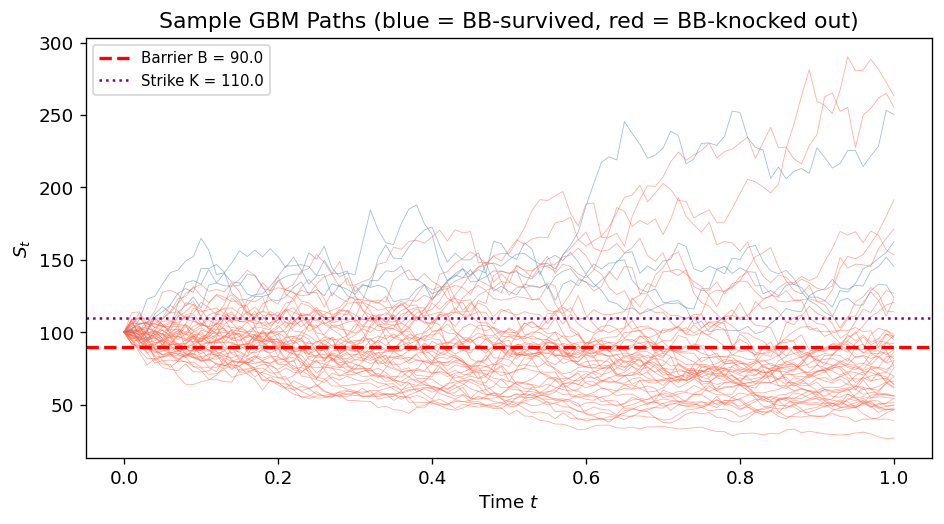

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# Generate a small batch of illustrative paths
np.random.seed(7)
n_show = 50
h_plot = T / N_steps
Z_show = np.random.standard_normal((n_show, N_steps))
logS_show = np.log(s0) + np.cumsum(
    (r - 0.5 * sigma**2) * h_plot + sigma * np.sqrt(h_plot) * Z_show, axis=1)
S_show = np.exp(logS_show)
S_full = np.hstack([np.full((n_show, 1), s0), S_show])
t_grid = np.linspace(0, T, N_steps + 1)

lnB = np.log(B)

# independent RNG for bridge-crossing draws (keeps it reproducible)
rng = np.random.default_rng(123)

for i in range(n_show):
    S_path = S_full[i]              # length N_steps + 1
    logS_path = np.log(S_path)

    l_prev = logS_path[:-1] - lnB   # l_k
    l_curr = logS_path[1:]  - lnB   # l_{k+1}

    # If any endpoint is below barrier, crossing is certain (continuous path must have crossed)
    if np.any((l_prev <= 0) | (l_curr <= 0)):
        survived_bb = False
    else:
        # Brownian-bridge crossing probabilities per interval
        p_cross = np.exp(-2.0 * l_prev * l_curr / (sigma**2 * h_plot))

        # Sample whether a crossing occurred in any interval
        U = rng.random(size=p_cross.shape[0])
        survived_bb = not np.any(U < p_cross)

    col = 'steelblue' if survived_bb else 'tomato'
    ax.plot(t_grid, S_path, lw=0.5, alpha=0.5, color=col)

ax.axhline(B, color='red',    lw=2, ls='--', label=f'Barrier B = {B}')
ax.axhline(K, color='purple', lw=1.5, ls=':',  label=f'Strike K = {K}')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$S_t$')
ax.set_title('Sample GBM Paths (blue = BB-survived, red = BB-knocked out)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 Convergence Study (Number of Paths)

We run the estimator for increasing $N$ and verify convergence to the analytical benchmarks.

In [9]:
Ns = [1000, 2000, 5000, 10_000, 20_000, 50_000, 100_000, 200_000, 1_000_000]

conv = {'price': [], 'price_se': [],
        'delta': [], 'delta_se': [],
        'vega':  [], 'vega_se':  []}

for Ni in Ns:
    ri = mc_barrier_pathwise(Ni, N_steps, s0, r, sigma, T, B, K, seed=1)
    for key in ['price', 'price_se', 'delta', 'delta_se', 'vega', 'vega_se']:
        conv[key].append(ri[key])

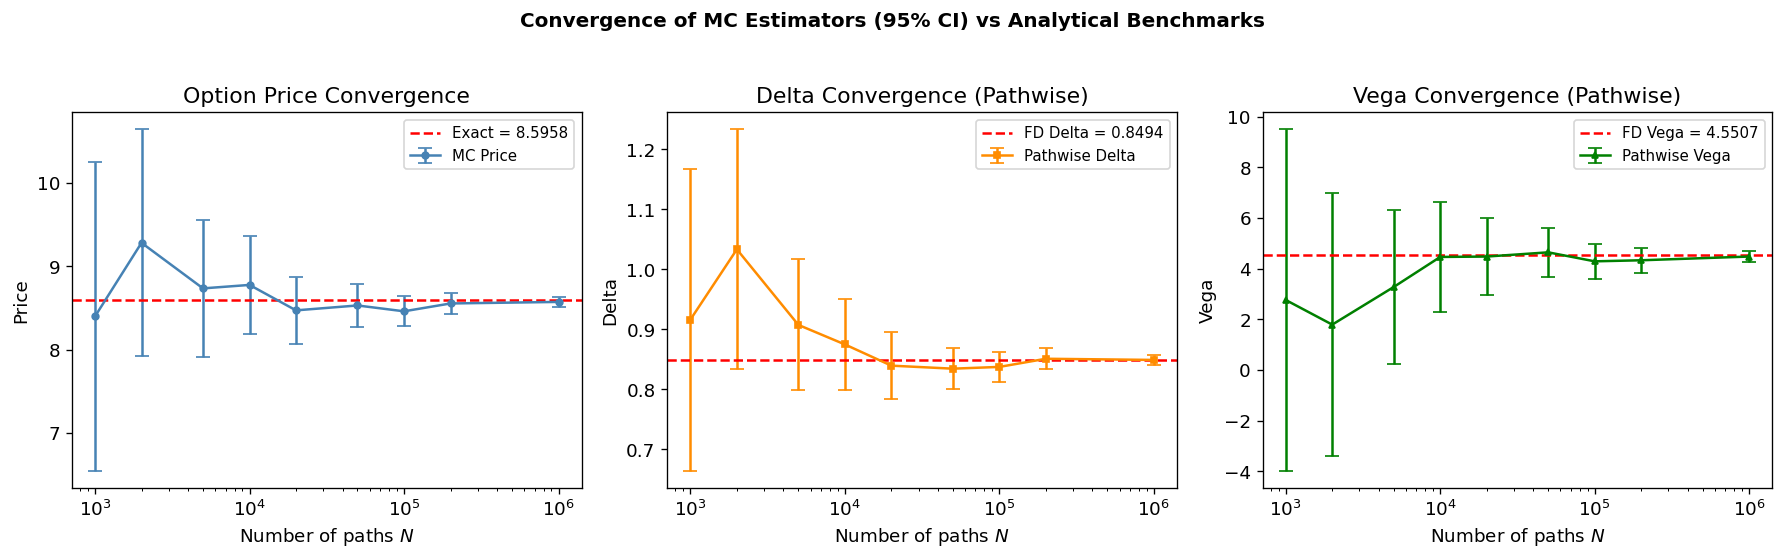

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Price convergence
ax = axes[0]
ax.errorbar(Ns, conv['price'], yerr=[1.96 * s for s in conv['price_se']],
            fmt='o-', color='steelblue', capsize=4, ms=4, label='MC Price')
ax.axhline(V_exact, color='red', ls='--', lw=1.5, label=f'Exact = {V_exact:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Number of paths $N$')
ax.set_ylabel('Price')
ax.set_title('Option Price Convergence')
ax.legend(fontsize=9)

# Delta convergence
ax = axes[1]
ax.errorbar(Ns, conv['delta'], yerr=[1.96 * s for s in conv['delta_se']],
            fmt='s-', color='darkorange', capsize=4, ms=4, label='Pathwise Delta')
ax.axhline(Delta_fd, color='red', ls='--', lw=1.5, label=f'FD Delta = {Delta_fd:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Number of paths $N$')
ax.set_ylabel('Delta')
ax.set_title('Delta Convergence (Pathwise)')
ax.legend(fontsize=9)

# Vega convergence 
ax = axes[2]
ax.errorbar(Ns, conv['vega'], yerr=[1.96 * s for s in conv['vega_se']],
            fmt='^-', color='green', capsize=4, ms=4, label='Pathwise Vega')
ax.axhline(Vega_fd, color='red', ls='--', lw=1.5, label=f'FD Vega = {Vega_fd:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Number of paths $N$')
ax.set_ylabel('Vega')
ax.set_title('Vega Convergence (Pathwise)')
ax.legend(fontsize=9)

fig.suptitle('Convergence of MC Estimators (95% CI) vs Analytical Benchmarks',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 4.3 Weak Convergence in Time Steps ($n$)

We verify $O(h)$ weak convergence by varying the number of time steps $n$ with a fixed large number of paths. The Brownian-bridge correction should give bias proportional to the step size $h = T/n$.

In [11]:
n_values = [10, 20, 50, 100, 200, 500]
N_fixed  = 200_000

weak = {'n': n_values, 'price': [], 'price_se': [],
        'delta': [], 'delta_se': [], 'vega': [], 'vega_se': []}

for ni in n_values:
    ri = mc_barrier_pathwise(N_fixed, ni, s0, r, sigma, T, B, K, seed=SEED)
    for key in ['price', 'price_se', 'delta', 'delta_se', 'vega', 'vega_se']:
        weak[key].append(ri[key])
    print(f"  n={ni:>4d}:  Price={ri['price']:.5f}  Delta={ri['delta']:.5f}  Vega={ri['vega']:.4f}")

  n=  10:  Price=8.57460  Delta=0.84565  Vega=4.5712
  n=  20:  Price=8.62992  Delta=0.85346  Vega=4.5603
  n=  50:  Price=8.44128  Delta=0.83593  Vega=4.3530
  n= 100:  Price=8.55519  Delta=0.86562  Vega=4.0210
  n= 200:  Price=8.44762  Delta=0.85645  Vega=3.8597
  n= 500:  Price=8.45651  Delta=0.85249  Vega=4.0619

Weak convergence study complete.


In [12]:
# High-accuracy reference using very fine time grid
n_ref = 2000   # large enough so time discretisation bias is negligible
ref = mc_barrier_pathwise(N_fixed, n_ref, s0, r, sigma, T, B, K, seed=SEED)

Price_ref = ref['price']
Delta_ref = ref['delta']
Vega_ref  = ref['vega']

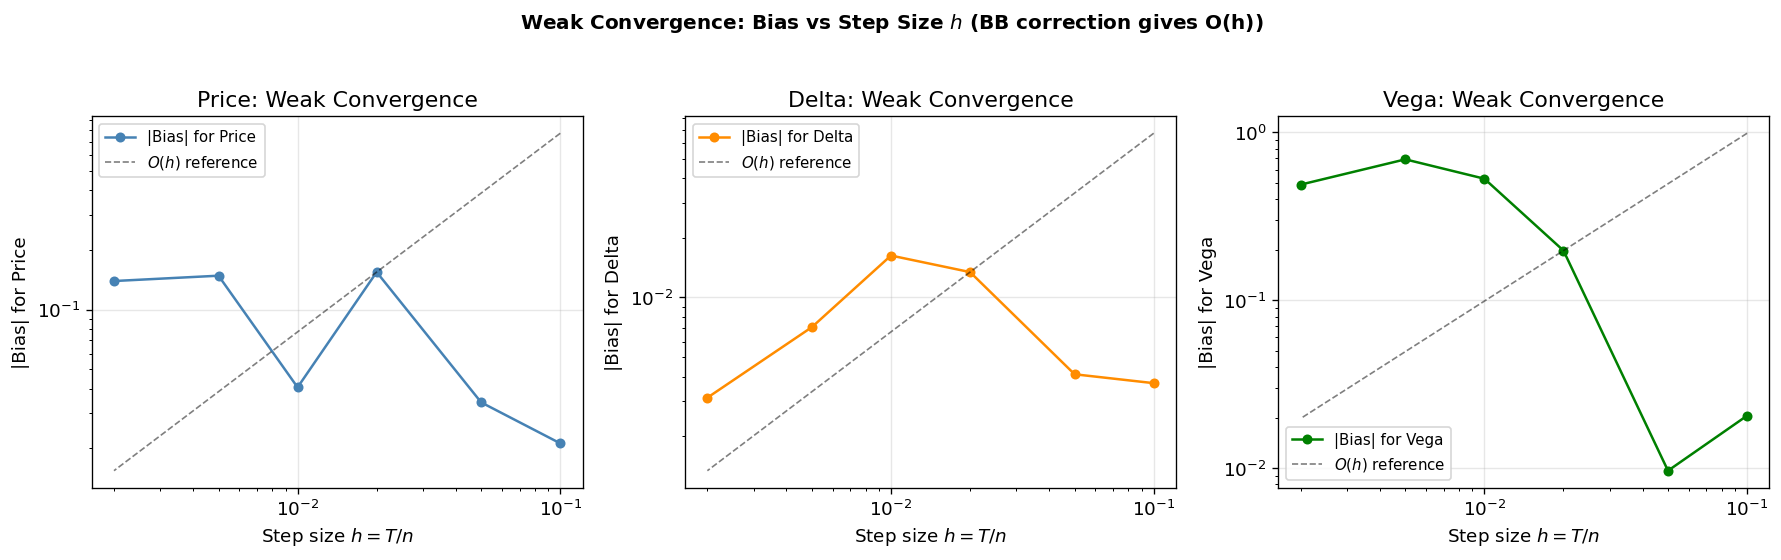

In [13]:
h_vals = [T / ni for ni in n_values]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, qty, exact, label, color in zip(
    axes,
    ['price', 'delta', 'vega'],
    [V_exact, Delta_fd, Vega_fd],
    ['Price', 'Delta', 'Vega'],
    ['steelblue', 'darkorange', 'green']
):
    bias = np.abs(np.array(weak[qty]) - exact)
    ax.loglog(h_vals, bias, 'o-', color=color, ms=5, label=f'|Bias| for {label}')
    # Reference O(h) line
    h_ref = np.array(h_vals)
    c = bias[2] / h_ref[2]  # fit at middle point
    ax.loglog(h_ref, c * h_ref, 'k--', lw=1, alpha=0.5, label='$O(h)$ reference')
    ax.set_xlabel('Step size $h = T/n$')
    ax.set_ylabel(f'|Bias| for {label}')
    ax.set_title(f'{label}: Weak Convergence')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Weak Convergence: Bias vs Step Size $h$ (BB correction gives O(h))',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

### 4.4 Comparison: With vs Without Brownian-Bridge Correction

To highlight the value of the BB correction, we compare the naive (discrete monitoring only) estimator against the corrected version.

 Comparison: With vs Without Brownian-Bridge Correction

To highlight the value of the BB correction, we compare the naive (discrete monitoring only) estimator against the corrected version.

In [14]:
def mc_barrier_naive(N, n, s0, r, sigma, T, B, K, seed=42):
    """Naive discrete-monitoring MC estimator (no BB correction)."""
    np.random.seed(seed)
    h      = T / n
    sqrt_h = np.sqrt(h)
    disc   = np.exp(-r * T)
    
    Z = np.random.standard_normal((N, n))
    logS = np.log(s0) + np.cumsum(
        (r - 0.5 * sigma**2) * h + sigma * sqrt_h * Z, axis=1)
    S = np.exp(logS)
    
    survived = np.all(S > B, axis=1).astype(float)
    ST = S[:, -1]
    f  = disc * np.maximum(ST - K, 0.0) * survived
    
    return np.mean(f), np.std(f, ddof=1) / np.sqrt(N)

print(f"{'n':>6s}  {'Naive Price':>14s}  {'BB-Corrected':>14s}  {'Exact':>12s}")
print("-" * 52)
for ni in [10, 20, 50, 100, 200, 500]:
    p_naive, _ = mc_barrier_naive(200_000, ni, s0, r, sigma, T, B, K, seed=SEED)
    ri = mc_barrier_pathwise(200_000, ni, s0, r, sigma, T, B, K, seed=SEED)
    print(f"{ni:>6d}  {p_naive:>14.6f}  {ri['price']:>14.6f}  {V_exact:>12.6f}")

     n     Naive Price    BB-Corrected         Exact
----------------------------------------------------
    10       13.272410        8.574599      8.595814
    20       12.091452        8.629919      8.595814
    50       10.736725        8.441285      8.595814
   100       10.304866        8.555193      8.595814
   200        9.668465        8.447615      8.595814
   500        9.262736        8.456508      8.595814


Later Claude recomendation :
Delta & Vega per-path distributions (histograms) — you had these in the earlier draft but dropped them. They show the heavy tails of the vega estimator and justify why SE is larger for vega. Easy win.
SE decay vs N on log-log — plot standard error against NN
N and overlay the theoretical O(1/N)O(1/\sqrt{N})
O(1/N​) line. This validates that your estimator has finite variance (not obvious given the product of survival weights).

Naive vs BB weak convergence on the same plot — right now Section 4.4 is just a table. A log-log plot showing |bias| vs hh
h for both estimators side-by-side would make the O(h)O(h)
O(h) improvement visually striking. The naive estimator has O(h)O(\sqrt{h})
O(h​) bias, the BB-corrected has O(h)O(h)
O(h).

**Pathwise vs bump-and-revalue Greeks** — estimate Delta/Vega by bumping s0s_0
s0​ or σ\sigma
σ and re-running MC with the *same random numbers*. This gives a second independent validation beyond the analytic FD, and shows the pathwise method has lower variance for the same cost.

Sensitivity to barrier level BB
B — plot price, Delta, Vega as functions of BB
B (say B∈[70,95]B \in [70, 95]
B∈[70,95]). As B→s0B \to s_0
B→s0​, the Greeks blow up and the estimator variance increases. This is interesting for the discussion section.

Minor issues I noticed:

Your weak convergence plot computes ref with n=2000n=2000
n=2000 but then still plots bias against
V_exact, Delta_fd, Vega_fd — the ref results go unused. Either remove that cell or use it as the benchmark (which would isolate discretization bias from the continuous-vs-discrete gap).
The sample paths plot uses BB *sampling* (drawing U<pcrossU < p_{\text{cross}}
U<pcross​) to color paths. That's fine conceptually, but it's inconsistent with the actual estimator which uses *weights* not binary draws. You could add a note clarifying this, or color by W>0.5W > 0.5
W>0.5 vs W≤0.5W \leq 0.5
W≤0.5 using the actual survival weight.

The ! rediscuss choice of epsilons comment is still in the notebook — make sure to either address it or remove it before submission.